# XX. Summary of germination models

## Week 13/2026

_Boyan Mihaylov, MSc Computational Science (UVA/VU)_

This notebook provides a systematic summary of all diffusion-driven germination models in the study. Furthermore, a reparameterisation framework is presented for their simplification.

## 1. Geometric variables

A spore is idealised as a sphere with a radius $r_s$, a surface area $A_s=4\pi r_s^2$ and a volume $V_s=4/3 \pi r_s^3$. The cell wall can be viewed as the outermost shell of this sphere, consisting of two thinner shells: an outer, hydrophobin-rich layer with a thickness $h_\textrm{hp}$ and an inner, polysaccharide-rich layer with a thickness $h_{\textrm{ps}}$.

The volume of the inner cell wall is considered the main compartment of inducer saturation. The total volume can be calculated as

$$
V_{\textrm{ps}}=\frac{4}{3}\pi\left[(r_s-d_{\textrm{hp}})^3-(r_s-d_{\textrm{hp}}-d_{\textrm{ps}})^3\right],
$$

which reflects the subtraction of the protoplast (membrane included) from the internal volume without the outer cell wall. Since the thickness of the hydrophobin layer is determined by the size of the hydrophobin rodlets, it can be considered nearly constant. On the other hand, the spore radius and the inner cell wall may exhibit much larger variations. For this reason, the spore radius $r_s$ can be modelled by a normally distributed random variable $R$ with a mean $\mu_R$ and a standard deviation $\sigma_R$. Similarly, the inner cell wall thickness can be modelled by a random variable $H$ with a mean $\mu_H$ and a standard deviation $\sigma_H$. It is important to consider that the inducer can occupy at most only the vacant fraction of the total volume, which according to studies[1] is approximately 24%. Thus, the expression for the effective inner cell wall volume becomes

$$
V_{\textrm{ps, eff}}=0.24\frac{4}{3}\pi\left[(R-d_{\textrm{hp}})^3-(R-d_{\textrm{hp}}-H)^3\right].
$$

Similarly, the other geometric variables can incorporate the random spore radius:

$$
A_s=4\pi R^2,
$$

$$
V_s=4/3 \pi R^3.
$$

Assuming that spores at an inoculum density of $\rho_s$ are positioned in a regular grid, a designated volume per spore can be defined as

$$
\begin{equation}
V_{\textrm{des}}=\frac{1}{\rho_s}.
\end{equation}
$$

Even if molecules diffuse over its boundaries into adjacent volumes, this occurs in a symmetric fashion, so that the net quantity of molecules within a volume remains preserved. Consecutively, one can separate this volume into the space occupied by the spore, $V_s$, and that remaining for the medium, $V_{\textrm{free}}=V_{\textrm{des}}-V_s$. A volume fraction, denoting the percentage per unit volume occupied by the conidia, can be defined as $\phi=\rho_s V_s$.

## 2. Main molecular components

Germination is considered to be primarily dependent on two molecular actors - an inhibitor $\textrm{I}$ (e.g. 1-octen-3-ol) and an inducer $\textrm{C}$ (e.g. alanine). There are 4 relevant types of concentration:
- $c_{\textrm{in}}^{\textrm{I}}$ - concentration of inhibitor in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{I}}$ - concentration of inhibitor in the extracellular medium;
- $c_{\textrm{in}}^{\textrm{C}}$ - concentration of inducer in the interior side of the cell wall;
- $c_{\textrm{out}}^{\textrm{C}}$ - concentration of inducer in the extracellular medium.

At inoculation, the interior concentration of inhibitor is defined as

$$
c_{\textrm{in}}^{\textrm{I}}(t=0)=c_0.
$$

Furthermore, any exterior concentration of inhibitor present at inoculation is defined as

$$
c_{\textrm{out}}^{\textrm{I}}(t=0)=c_{\textrm{ex}}^{\textrm{I}}.
$$

In most cases in this study, $c_{\textrm{ex}}^{\textrm{I}}=0$.

The inhibitor molecules strive to equilibrate across the cell wall. Taking into account the density of spores as sources of inhibitor dispersal, the internal inhibitor concentration at any spore over time can be calculated as

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}}\right] c_0+(1-\phi)\left(1-e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right)c_{\textrm{ex}}^{\textrm{I}}
$$

or simply

$$
c_{\textrm{in}}^{\textrm{I}}(t)=\left[\phi+(1-\phi)e^{-\frac{t}{\tau^{\textrm{I}}(1-\phi)}}\right] c_0
$$

if $c_{\textrm{ex}}^{\textrm{I}}=0$. The two important variables here are the volume fraction $\phi$ and

$$
\tau^{\textrm{I}}=\frac{V_s}{P_{\textrm{eff}}^{\textrm{I}}A_s},
$$

which is a characteristic permeation time related to the volume to surface area ratio of the spore and the effective permeation constant $P_{\textrm{eff}}^{\textrm{I}}$ of the inhibitor, valid for the entire cell wall complex. 

A picture of the induction mechanism may be more accurately painted using the available knowledge about carbon-sensitive receptor proteins tethered to the cell membrane. This supports the representation of the inner cell wall as an inducer-soaking compartment, with the outer cell wall being a diffusion-limiting barrier. In the inhibitor case, however, the situation is different. Since there is insufficient evidence for the exact locations where the inhibitor originates and exerts its effect, it is harder to generalise which volumes are relevant for its concentration equilibration and which cell wall layers should be considered in the permeation between spore and medium. Therefore, the full spore volume and area ($V_s$ and $A_s$) are taken as approximate reference and $P_{\textrm{eff}}^{\textrm{I}}$ may account for any number of diffusion-limiting barriers: the cell membrane, the inner cell wall, the hydrophobin layer. In any combination of $M$ of these layers, the permeability is computed through the expression

$$
\frac{1}{P_{\textrm{eff}}^{\textrm{I}}}=\sum_i^M{\frac{1}{P_i^{\textrm{I}}}}.
$$

Contrary to this, the equilibration of inducer concentration over the hydrophobin barrier only takes into account a permeation constant $P_{\textrm{eff}}^{\textrm{C}}$ of the inducer molecule through the rodlet layer and obeys the formula

$$
c_{\textrm{in}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}(1-e^{-t/\tau^{\textrm{C}}}),
$$

where $c_{\textrm{ex}}^{\textrm{C}}$ is the initial external inducer concentration (considered effectively constant) and

$$
\begin{equation}
\tau^{\textrm{C}}=\frac{V_{\textrm{ps, eff}}}{P_s^{\textrm{C}}A_s},
\end{equation}
$$

i.e. the characteristic permeation time is dependent on the inner cell wall compartment and not on the entire spore volume.

## 3. Germination mechanisms

Under the general assumption that both the release of inhibition and a strong enough inducing signal must be present for germination, the break of dormancy can be expressed as an instantaneous event that depends on a twofold criterion:

$$
c_{\textrm{in}}^{\textrm{I}}(t) < \gamma c_0^{\textrm{I}} \quad \textrm{and} \quad s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right) > \omega.
$$

The first criterion states that germination becomes possible when the internal inhibitor concentration is below a certain fraction $\gamma$ (with $0<\gamma<1$) of its initial concentration. By specifying

$$
c_{\textrm{in}}^{\textrm{I}}(t) = \beta c_0,
$$

where

$$
\beta=\phi+(1-\phi)e^{-\frac{t}{\tau(1-\phi)}},
$$

one can simplify the criterion as

$$
\beta < \gamma.
$$

It is natural to assume that the threshold value $\gamma$ is not universal for all spores but rather depends on a complex network of factors, which can be reflected by modelling it as a Normal random variable $X$, with mean $\mu_X$ and standard deviation $\sigma_X$.

It can be assumed that at $t=0$ barely any spore has instantaneously reached its inhibitor depletion threshold. This imposes a constraint on $\sigma_X$ to not leave a significant portion of the upper Gaussian tail beyond $1$, which is the equivalent of a full initial inhibitor concentration. Therefore, instead of dealing with the $\sigma_X$ directly, a log-Normal distributed factor $\delta_X$ can be used, such that

$$
\sigma_X = \frac{1-\mu_X}{3}e^{-\delta_X},
$$

where the $3$ in the denomitator restricts the $X$ distribution to be within at least three standard deviations under unity.

The second criterion enables germination when an inducing signal produced by the inducer concentration inside the outer cell wall becomes larger than a certain threshold $\omega$ (with $0<\omega<1$) of the outside concentration (which for simplicity is considered constant). Due to the known mechanisms of ligation to receptor molecules, the inducing effect is not linear with the concentration but can be assumed to follow Michaelis-Menten dynamics:

$$
s\left(c_{\textrm{in}}^{\textrm{C}}(t)\right)=s_{\textrm{max}} \frac{c_{\textrm{in}}^\textrm{C}(t)}{K_s+c_{\textrm{in}}^\textrm{C}(t)}
$$

with a saturation level $s_{\textrm{max}}$ (set to $1$ to normalize the signal against the threshold) and a half-saturation constant $K_s$.

The assumption of Michaelis-Menten-type dynamics could not be made for the inhibitor due to lack of evidence, hence its simpler formulation. On the other hand, the inducer condition does not allow cancellations analogous to the inhibitor case (e.g. of $c_{\textrm{ex}}^{\textrm{C}}$), so we keep the full inequality expression.

Once again, the threshold $\omega$ may be influenced by many factors, so it is best modelled by a Normal random variable $Y$ with mean $\mu_Y$ and standard deviation $\sigma_Y$.

In the simplest case, when the inhibitor and inducer are non-interacting, the probability of a spore germinating at a given time can be expressed as

$$
p(t) = \mathbb{P}{(\beta < X \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_X{(\beta)}\right]\, F_Y{(s)} \, f_R(r_s) \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}},
$$

where

$$
F_X{(\beta)}=\Phi{\left(\frac{\beta(r_s, t)-\mu_X}{\sigma_X}\right)}
$$

and

$$
F_Y{(s)}=\Phi{\left(\frac{s(K_s^\textrm{C}, r_s, d_{\textrm{ps}}, t)-\mu_Y}{\sigma_Y}\right)}
$$

are cumulative distribution functions,

$$
f_R(r_s) = \frac{1}{\sqrt{2\pi}\sigma_R}\exp{\left(-\frac{(r_s-\mu_R)}{2\sigma_R^2}\right)}
$$

and

$$
f_H(d_{\textrm{ps}}) = \frac{1}{\sqrt{2\pi}\sigma_H}\exp{\left(-\frac{(d_{\textrm{ps}}-\mu_H)}{2\sigma_H^2}\right)}
$$

are Normal probability density functions, and a separate integral is taken over all possible values for the two random variables $R$ and $H$.

A constrain is imposed on all random variable parameters that their standard deviation must not exceed the order of the mean, otherwise they would produce unrealistically wide distributions. Therefore, instead of manipulating the $\sigma$ parameters directly, an exponent parameter $\delta$ is assigned to each random variable distribution, such that

$$
\sigma=\mu e^{-\delta}.
$$

In summary, the free parameters of this model are $P_{\textrm{eff}}^{\textrm{I}}$, $P_{\textrm{eff}}^{\textrm{C}}$, $K_s^\textrm{C}$, $\mu_X$, $\delta_X$, $\mu_Y$ and $\delta_Y$.

## 4. Basic interactions

The probability expression becomes more complex once interactions between the inhibitor and the inducer come into play. Starting from the basic model, several primary nodes are pinpointed that may interact with each other:

- the inducing signal strength $s$;
- the induction threshold $\omega$;
- the inhibition threshold $\gamma$;
- the cell wall permeability for inducer and inhibitor molecules.

This enables outlining the following interactions of interest, labelled by capital letters:

- ($\textrm{A}$) the inducer causes an increased cell wall permeability (aligned with dormancy-breaking processes in spores), making it easier for inducing molecules to reach the membrane-bound receptors and for inducer molecules to deplete.
- ($\textrm{B}$) the inducer increases the inhibition threshold by promoting (via mass-action dynamics) an effect that makes the spore less succeptible to inhibition;
- ($\textrm{C}$) the inhibitor reduces the maximum possible signal strength, either by directly blocking the binding sites or by some other mass-action effect further down the signalling pathway (inhibitor dynamics expression multiplied with the signal strength);
- ($\textrm{D}$) the inhibitor causes a reduced cell wall permeability (aligned with observations of dormant spores), making it more difficult for inducing molecules to reach the membrane-bound receptors and for inducer molecules to deplete;
- ($\textrm{E}$) the inhibitor increases the induction threshold by promoting (via mass-action dynamics) an effect that makes it more difficult for the inducing signal to trigger germination (standard Michaelis-Menten effect added to threshold);

For the sake of completeness, all possible combinations of these effects are considered, despite the concern that multifacetted effect of the same actor on several nodes may be less biologically plausible. Furthermore, in a scenario where one actor affects the pathway of the other, the former may or may not also contribute to germination directy (e.g. an inhibitor may affect the induction threshold but also co-trigger germination by depleting under its threshold). It is up to the sensitivity analysis to determine whether the prediction power of the model in such cases is overshadowed by its increased complexity.

### 4.1. Inducer modulates permeability (A)

**!!!!!!!!!!!!!!!CORRECT THIS!!!!!!!!!!!!!!!**

In this scenario, it is considered that the inducing signal arising from the concentration of the carbon source yields a transformation of the permeation constant for both the inducer and the inhibitor molecules. In its simplest formulation, this can happen as a linear offset from a base permeability for small inducer concentrations and reach a saturating permeability for high-inducer concentration $P_{\textrm{max}}$ (here heuristically set to $10^{3}\ \mu\textrm{m/s}$).

For the inducer and the inhibitor permeability, respectively:

$$
P_{\textrm{perturbed}}^{\textrm{C}}=P_{\textrm{max}}-(P_{\textrm{max}}-P_{\textrm{base}}^{\textrm{C}})e^{-\lambda^{\textrm{C}}s},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=P_{\textrm{max}}-(P_{\textrm{max}}-P_{\textrm{base}}^{\textrm{I}})e^{-\lambda^{\textrm{C}}s},
$$

where $\lambda^{\textrm{C}}$ controls the rate at which the permeability shifts based on the concentration-based inducing signal. If the signal additionally triggers germination by surpassing the threshold $\omega$, the half-saturation constant $K_s^\textrm{C}$ implicit in the term is the same as for the permeability-decreasing effect.

The dynamic modulation of the permeability creates a system of ODEs that does not have a closed-form solution and cannot be computed as an integral, like in the previous case. Instead, a numerical Monte Carlo integration of the differential equations is necessary to account for all possible values of the random variable distributions $R$ and $H$.

First, the simpler case is observed where the **inducer only affects the cell wall permeability** and does not directly trigger germination through a threshold-based criterion. The change of inhibitor concentration in the spore over time is given by the ODE

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{I}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{I}}A_s}{V_s}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right],
\end{equation}
$$

The outside concentration changes as

$$
\begin{equation}
\frac{d{c_{\textrm{out}}^{\textrm{I}}}}{d{t}}=\left(\frac{P_{\textrm{perturbed}}^{\textrm{I}}A_s}{V_{\textrm{free}}}\right)\left[c_{\textrm{in}}^{\textrm{I}}{(t)}-c_{\textrm{out}}^{\textrm{I}}{(t)}\right].
\end{equation}
$$

The concentration drop of inducer across the outer cell wall, on the other hand, follows the formula

$$
\begin{equation}
\frac{d{\Delta c^{\textrm{C}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{C}}A_s}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}\right],
\end{equation}
$$

Since $\Delta c^{\textrm{C}}=c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{out}}^{\textrm{C}}{(t)}$ and $c_{\textrm{out}}^{\textrm{C}}{(t)}=c_{\textrm{ex}}^{\textrm{C}}$ is a constant, this equates to

$$
\begin{equation}
\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}=-\left(\frac{P_{\textrm{perturbed}}^{\textrm{C}}A_s}{V_{\textrm{ps}}}\right)\left[c_{\textrm{in}}^{\textrm{C}}{(t)}-c_{\textrm{ex}}^{\textrm{C}}\right].
\end{equation}
$$

Thus, the system of coupled ODEs $\dot{c}_{\textrm{in}}^{\textrm{I}}=\frac{d{\Delta c^{\textrm{I}}}}{d{t}}$, $\dot{c}_{\textrm{out}}^{\textrm{I}}=\frac{d{\Delta c^{\textrm{C}}}}{d{t}}$ and $\dot{c}_{\textrm{in}}^{\textrm{C}}=\frac{d{c_{\textrm{in}}^{\textrm{C}}}}{d{t}}$ needs to be solved. The initial conditions for these ODEs are $c_{\textrm{in}}^{\textrm{I}}{(0)}=c_0$, $c_{\textrm{out}}^{\textrm{I}}{(0)}=0$ and $c_{\textrm{in}}^{\textrm{C}}{(0)}=0$. The initial inhibitor concentration inside the spore ($c_0$) is certainly not uniform over all spores and is therefore modelled by another random variable, $O$, normally distributed with mean $\mu_O$ and standard deviation $\sigma_O$. The Monte Carlo integration must therefore also sample this distribution for possible inhibitor/inducer concentration evolutions.

At specific time points of these evolutions, the germination percentage is determined by comparing the concentrations to a sample of thresholds. If both the inhibitor and the inducer directly influence germination through a threshold mechanism, a sample is drawn from each of their respective threshold distributions. Alternatively, the inducer's role may be only indirect, in which case a sample is only drawn from the $X$ distribution.

In summary, the free parameters used in the model with a single direct influence are $P_{\textrm{eff}}^{\textrm{I}}$, $P_{\textrm{eff}}^{\textrm{C}}$, $K_s^\textrm{C}$, $\lambda^C$, $\mu_O$, $\delta_O$, $\mu_X$ and $\delta_X$. If the inducer also directly co-determines germination, $\mu_Y$ and $\delta_Y$ are added to these.

### 4.2. Inducer modulates inhibition threshold (B)

In this type of interaction, the inducing signal shifts the threshold for inhibition upwards, making it more attainable with a smaller release of inhibitor from the spore. This is assumed to work as a linear perturbation of $\gamma$ by the inducing signal $s$ scaled by a factor $k_\gamma$:

$$
\gamma' = \gamma + k_\gamma s.
$$

When only this interaction is present, it suffices to modify the threshold of the basic two-factor germination model with the above expression:

$$
p(t) = \mathbb{P}{(\beta < X + k_\gamma s \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_{X'}{(\beta)}\right]\, F_Y{(s)} \, f_R(r_s) \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}},
$$

where

$$
F_{X'}{(\beta)}=\Phi{\left(\frac{\beta(r_s, t)-\mu_X- k_\gamma s}{\sigma_X}\right)}.
$$

This interaction also allows for the assumption that the inducer does not directly trigger germination, but only affects it via the threshold shift. In such case,

$$
p(t) = \mathbb{P}{(\beta < X + k_\gamma s \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_{X'}{(\beta)}\right]\, f_R(r_s) \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}}.
$$

### 4.3. Inhibitor attenuates inducing signal (C)

Despite lacking evidence for this, the inhibitor may oppose germination by causing the blocking of binding sites for the inducer or for some of its downstream products, perhaps directly or, more likely, through another intermediary molecule. In this case, on may adopt classical inhibitor dynamics in the form of a Michaelis-Menten system. For the current purposes, it is thought that the blocking molecule functionally differs from the substrate, enough to assume non-competitive inhibition. Therefore, the modulated induction signal is

$$
s'{(c_{\textrm{in}}^{\textrm{I}})}=s{(c_{\textrm{in}}^{\textrm{C}})}\ \frac{1}{1+\left(\frac{c_{\textrm{in}}^{\textrm{I}}}{K_I}\right)^n},
$$

with $s$ as defined previously, $K_I$ a half-inhibition constant and $n$ a Hill exponent.

When this is the only interaction present, the simple two-factor germination model is modified to account for $s'$:

$$
p(t) = \mathbb{P}{(\beta < X \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\int_0^{\infty}{\left[1-F_X{(\beta)}\right]\, F_Y{(s')} \, f_R(r_s) \, f_H(d_{\textrm{ps}})\, f_O(c_0)d{r_s}}d{d_{\textrm{ps}}}}d{c_0}},
$$

where

$$
F_Y{(s')}=\Phi{\left(\frac{s'(K_s^\textrm{C}, K_I, n, r_s, d_{\textrm{ps}}, c_0, t)-\mu_Y}{\sigma_Y}\right)}
$$

and

$$
f_O(c_0) = \frac{1}{\sqrt{2\pi}\sigma_O}\exp{\left(-\frac{(c_0-\mu_O)}{2\sigma_O^2}\right)}.
$$

It is important to notice that this expression is not independent of $c_0$ anymore, hence the additional integral over all $c_0$ values from the $O$ distribution. 

Here, too, the inhibitor may only play a role in reducing the inductory signal and the inhibition threshold criterion can be omitted:

$$
p(t) = \mathbb{P}{(\beta < X \: \cap \: \psi > Y \: | \: \rho_s, t)}=\int_0^{\infty}{\int_0^{\infty}{\left[1-F_X{(\beta)}\right]\, f_R(r_s) \, f_H(d_{\textrm{ps}})d{r_s}}d{d_{\textrm{ps}}}}.
$$

### 4.4. Inhibitor modulates permeability (D)

The inverse effect of (A) would be to have the presence of inhibitor reduce the cell wall permeability - something that is plausible in a dormant, hard-walled spore. The true, baseline permeability for both the inducer and the inhibitor molecules could only be reach upon the complete depletion of inhibitor from the spore volume. Otherwise, the permeation constant would diminish toward zero. This can be expressed as follows:

$$
P_{\textrm{perturbed}}^{\textrm{C}}=P_{\textrm{base}}^{\textrm{C}}e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=P_{\textrm{base}}^{\textrm{I}}e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}}.
$$

Similarly to (A), $\lambda^{\textrm{I}}$ amplifies the effect of internal inhibitor concentration. The molecular concentrations and the subsequent germination incidence are computed by numerically integrating an ODE system like in (A).

### 4.5. Inhibitor modulates induction threshold (E)

Analogous to (B), the inhibitor may shift the threshold for induction upwards, making it harder for an inducing signal to trigger germination when inhibitor levels are high. To ensure that this shift remains bounded, this time a Michaelis-Menten term is also adopted for the inhibitory signal:

$$
b\left(c_{\textrm{in}}^{\textrm{I}}(t)\right)=\frac{c_{\textrm{in}}^\textrm{I}(t)}{K_b+c_{\textrm{in}}^\textrm{I}(t)}.
$$

Thus, the shifted induction threshold becomes

$$
\omega' = \omega + k_\omega b.
$$

Starting from the interaction-free model, the CDF $F_{Y}{(\omega)}$ is exchanged for

$$
F_{Y'}{(s)}=\Phi{\left(\frac{s(K_s^\textrm{C}, r_s, d_{\textrm{ps}}, t)-\mu_Y-k_\omega b}{\sigma_Y}\right)}
$$

and, like in (B), a third integral over $c_0$ is incorporated. Again, the germination trigger may be activated by both molecular species or solely by the inducer.

## 5. Double interactions

It is conceivable that the germination factors determine the break of dormancy by leveraging more than one mode of interaction in their biochemical pathways. The following model variants arise from the combinations of single-interaction models, taking further into account whether one of the factors is omitted from direct germination triggering or not:

- ($\textrm{AB}$) the inducing signal modulates the cell wall permeability and shifts the inhibition threshold; germination is triggered by both criteria together or by inhibitor depletion alone;
- ($\textrm{AC}$) the inducing signal modulates the cell wall permeability and is suppressed by the inhibitor; germination is triggered by both criteria together, by inhibitor depletion alone or by a sufficiently strong induction alone;
- ($\textrm{AD}$) the inducing signal and the inhibitor both modulate the cell wall permeability; germination is triggered by both criteria together, by inhibitor depletion alone or by a sufficiently strong induction alone;
- ($\textrm{AE}$) the inducing signal modulates the cell wall permeability and the inhibitor shifts the induction threshold; germination is triggered by both criteria together or by a sufficiently strong induction alone;
- ($\textrm{BC}$) the inhibitor suppresses the inducing signal, which in turn shifts the inhibition threshold; germination is triggered by both criteria together or by inhibitor depletion alone;
- ($\textrm{BD}$) the inhibitor modulates the cell wall permeability and the induction signal shifts the inhibition threshold; germination is triggered by both criteria together or by inhibitor depletion alone;
- ($\textrm{BD}$) the inhibitor shifts the induction threshold and the induction signal shifts the inhibition threshold; germination is triggered by both criteria together;
- ($\textrm{CD}$) the inhibitor modulates the cell wall permeability and suppresses the induction signal; germination is triggered by both criteria together or by a sufficiently strong induction alone;
- ($\textrm{CE}$) the inhibitor suppresses the induction signal and shifts the induction threshold; germination is triggered by both criteria together or by a sufficiently strong induction alone;
- ($\textrm{DE}$) the inhibitor modulates the cell wall permeability and shifts the induction threshold; germination is triggered by both criteria together or by a sufficiently strong induction alone;

### 5.1 Inducer and inhibitor modulate permeability (AD)

**!!!!!!!!!!!!!!!CORRECT THIS!!!!!!!!!!!!!!!**

One particular variant that requires special attention is the model where both the inducer and the inhibitor modulate the permeability simultaneously. To express these two counteracting effects, the modified permeation constants are formulated as follows:

$$
P_{\textrm{perturbed}}^{\textrm{C}}=\left[P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{C}}-P_{\textrm{base}}^{\textrm{C}})e^{-\lambda^{\textrm{C}}s}\right]e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

$$
P_{\textrm{perturbed}}^{\textrm{I}}=\left[P_{\textrm{max}}-(P_{\textrm{max}}^{\textrm{I}}-P_{\textrm{base}}^{\textrm{I}})e^{-\lambda^{\textrm{C}}s}\right]e^{-\lambda^{\textrm{I}}c_{\textrm{in}}^\textrm{I}},
$$

In [1]:
using PyPlot
using Distributions
using Revise

Revise.includet("../src/germstats.jl")
Revise.includet("../src/germstats_gpu.jl")
Revise.includet("../src/conversions.jl")
Revise.includet("../src/datautils.jl")

using .GermStats
using .GermStatsGPU
using .Conversions
using .DataUtils

### Tests

In [6]:
# Testing procedure for a single model, comparting to sequential version

rho_s = inverse_mL_to_cubic_um(1e5)
t_max = 48*3600 # seconds
times = collect(LinRange(0.0f0, t_max, 1000))

anchor = Dict(
    :Pₛ => 1e-3,
    :Pₛ_cs => 1e-6,
    :μ_γ => 1e-3,
    :σ_γ => 1e-3,
    :neg_δ_γ => 1,
    :μ_ω => 0.3,
    :σ_ω=> 1e-1,
    :neg_δ_ω => 1,
    :s => 1e-3,
    :b => 1e-3,
    :μ_ψ => 0.5,
    :σ_ψ => 0.01,
    :K_cC => 0.02,
    :K_cI => 0.02,
    :K_I => 0.01,
    :k_C => 0.1,
    :n => 2,
    :k_I => 1.0
)

def_params = Dict(
    :μ_ξ => 2.65,
    :σ_ξ => 0.3,
    :c₀_cs => 0.01,
    :d_hp => 0.01,
    :μ_κ => 0.2,
    :σ_κ => 0.05
)


# # Default parameters
# def_params = Dict(
#     :μ_ξ => 2.65,
#     :σ_ξ => 0.3,
#     :c₀_cs => 0.01,
#     :d_hp => 0.01,
#     :μ_κ => 0.2,
#     :σ_κ => 0.05
# )

# param_dict = Dict(
#     :mu_R       => [2.65],
#     :sigma_R    => [0.3],
#     :mu_H       => [0.2],
#     :sigma_H    => [0.05],
#     :c_ex       => [0.01],
#     :P_I        => [1e-3],
#     :P_C        => [1e-6],
#     :mu_X       => [1e-3],
#     :sigma_X    => [1e-3],
#     :mu_Y       => [1e-1],
#     :sigma_Y    => [1e-1],
#     :K_s        => [0.01],
# )

n_samples = 100#0

param_dict = Dict(
    # :mu_O       => fill(0.5, n_samples),
    # :sigma_O    => fill(0.01, n_samples),
    :mu_O       => fill(1e-4, n_samples),
    :sigma_O    => fill(1e-4, n_samples),
    :mu_R       => fill(2.65, n_samples),
    :sigma_R    => fill(0.3, n_samples),
    :mu_H       => fill(0.2, n_samples),
    :sigma_H    => fill(0.05, n_samples),
    :c_ex       => fill(0.01, n_samples),
    :P_I        => fill(1e-3, n_samples),
    :P_C        => fill(1e-6, n_samples),
    :mu_X       => fill(1e-3, n_samples),
    :sigma_X    => fill(1e-3, n_samples),
    :mu_Y       => fill(0.3, n_samples),
    :sigma_Y    => fill(1e-1, n_samples),
    :K_s        => fill(0.02, n_samples),
    :K_b        => fill(0.02, n_samples),
    :K_I        => fill(0.01, n_samples),
    :lambda_I   => fill(1e-3, n_samples),
    :lambda_C   => fill(1e-3, n_samples),
    :k_gamma    => fill(0.1, n_samples),
    :k_omega    => fill(1.0, n_samples),
    :n          => fill(2, n_samples),
)

@time germination = compute_germination("independent", rho_s, times, param_dict)
@time germination_2 = compute_germination_response("independent", times, rho_s, merge(anchor, def_params))
# @time germination = compute_germination("feedback_combined_inducer_perm_thresh_inhibitor_signal", rho_s, times, param_dict)
# @time for _ in 1:n_samples
#     germination_2 = compute_germination_response("feedback_combined_inducer_perm_thresh_inhibitor_signal", times, rho_s, merge(anchor, def_params))
# end

# Fit Dantigny parameters to the germination data
@time for i in 1:n_samples
    fit_params = fit_dantigny_to_germination_curve(germination[i, :], times)
    println("Sample $i: Fit parameters: ", fit_params)
end

 10.152418 seconds (27.92 M allocations: 1.841 GiB, 6.84% gc time, 88.37% compilation time: 4% of which was recompilation)
  5.211006 seconds (8.82 M allocations: 759.107 MiB, 3.18% gc time, 98.18% compilation time)
Sample 1: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 2: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 3: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 4: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 5: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 6: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 7: Fit parameters: ([0.5505173730480555, 49523.246792672784, 2.178886447335104], 0.000783609457016773)
Sample 8: Fit 

Fit parameters: [0.5505173730480692, 49523.24679267411, 2.1788864473349623]
RMSE: 0.0007836094570167722


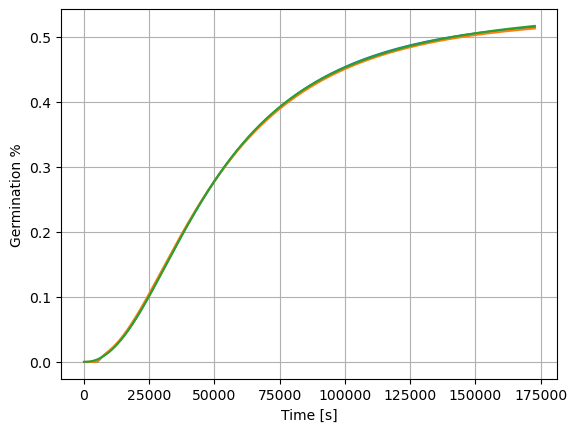

In [10]:
matplotlib.pyplot.close()

fit_params, rmse = fit_dantigny_to_germination_curve(germination[1, :], times)

println("Fit parameters: ", fit_params)
println("RMSE: ", rmse)

fig, ax = subplots()

ax.plot(times[2:end], germination[1, 2:end])
ax.plot(times, germination_2)
ax.plot(times, dantigny.(times, fit_params...))
# ax.plot(times, germination_3)
ax.grid()
ax.set_xlabel("Time [s]")
ax.set_ylabel("Germination %")
gcf()

In [8]:
function normal_cdf_wichura_cpu(x, μ, σ)
    z = (x - μ) / σ
    
    # Abramowitz and Stegun approximation (7.1.26)
    # Maximum error: 2.5 × 10⁻⁵
    b1 = Float32(0.319381530f0)
    b2 = Float32(-0.356563782f0)
    b3 = Float32(1.781477937f0)
    b4 = Float32(-1.821255978f0)
    b5 = Float32(1.330274429f0)
    p  = Float32(0.2316419f0)
    c  = Float32(0.39894228f0)
    
    abs_z = abs(z)
    t = 1.0f0 / (1.0f0 + p * abs_z)
    
    # Compute the CDF value
    cdf_val = 1.0f0 - c * exp(-0.5f0 * z * z) * t * 
              (b1 + t * (b2 + t * (b3 + t * (b4 + t * b5))))
    
    # Handle the sign
    return z < 0 ? 1.0f0 - cdf_val : cdf_val
end

# Test on CPU
using Distributions
μ_test = 2.0
σ_test = 1.5
x_test = 3.5f0

# Our implementation
our_result = normal_cdf_wichura_cpu(Float32(x_test), Float32(μ_test), Float32(σ_test))

# Distributions.jl for comparison
dist_result = cdf(Normal(μ_test, σ_test), x_test)

println("Our implementation: $our_result")
println("Distributions.jl:  $dist_result")
println("Error: $(abs(our_result - dist_result))")


Our implementation: 0.8413447
Distributions.jl:  0.841344746068543
Error: 3.1903809150080065e-8


--- Testing model 0 ---
--- Testing model Ai ---
Model index: 2
Threshold mode: 0
Constructing problem...
Starting solver...
Solutions complete.
--- Testing model A ---
Model index: 3
Threshold mode: 2
Constructing problem...
Starting solver...
Solutions complete.
--- Testing model Bi ---
--- Testing model B ---
--- Testing model Cc ---
--- Testing model C ---
--- Testing model Dc ---
Model index: 8
Threshold mode: 1
Constructing problem...
Starting solver...
Solutions complete.
--- Testing model D ---
Model index: 9
Threshold mode: 2
Constructing problem...
Starting solver...
Solutions complete.
--- Testing model Ec ---
--- Testing model E ---
--- Testing model ABi ---
Model index: 12
Threshold mode: 3
Constructing problem...
Starting solver...
Solutions complete.
--- Testing model AB ---
Model index: 13
Threshold mode: 5
Constructing problem...
Starting solver...
Solutions complete.
--- Testing model ACi ---
Model index: 14
Threshold mode: 0
Constructing problem...
Starting solver...

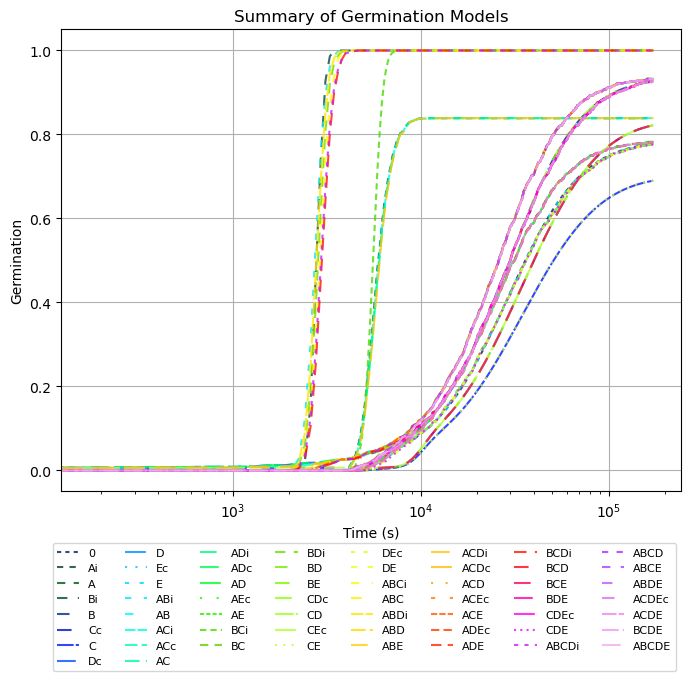

In [33]:
# Testing procedure for all models

aliases, combination_IDs, descriptions, param_key_sets = load_model_collection_ordered()

rho_s = inverse_mL_to_cubic_um(1e5)
t_max = 48*3600 # seconds
times = collect(LinRange(0.0f0, t_max, 1000))

n_samples = 1

param_dict = Dict(
    # :mu_O       => fill(0.5, n_samples),
    # :sigma_O    => fill(0.01, n_samples),
    :mu_O       => fill(1e-3, n_samples),
    :sigma_O    => fill(1e-3, n_samples),
    :mu_R       => fill(2.65, n_samples),
    :sigma_R    => fill(0.3, n_samples),
    :mu_H       => fill(0.2, n_samples),
    :sigma_H    => fill(0.05, n_samples),
    :c_ex       => fill(0.01, n_samples),
    :P_I        => fill(1e-3, n_samples),
    :P_C        => fill(1e-6, n_samples),
    :mu_X       => fill(1e-3, n_samples),
    :sigma_X    => fill(1e-3, n_samples),
    :mu_Y       => fill(0.25, n_samples),
    :sigma_Y    => fill(1e-1, n_samples),
    :K_s        => fill(0.015, n_samples),
    :K_b        => fill(0.015, n_samples),
    :K_I        => fill(0.0001, n_samples),
    :lambda_I   => fill(1.0, n_samples),
    :lambda_C   => fill(1.0, n_samples),
    :k_gamma    => fill(1.0, n_samples),
    :k_omega    => fill(400.0, n_samples),
    :n          => fill(1.2, n_samples),
)

# germination_results = zeros(length(aliases), length(times))

matplotlib.pyplot.close()
fig, ax = subplots(figsize=(8, 6))
cmap = get_cmap("gist_ncar", length(aliases)+5)

for (i, (alias, id)) in enumerate(zip(aliases, combination_IDs))
    println("--- Testing model $id ---")
    germination = compute_germination(alias, rho_s, times, param_dict)

    # if id == "0"
    #     col = "black"
    # else
    #     asd
    # end
    ax.plot(times, germination[1, :], label=id, color=cmap(i), alpha=0.8, dashes=(i % 10 + 1, i % 7 + 1))
end

ax.grid()
ax.set_xscale("log")
ax.legend(ncol=8, loc="upper right", bbox_to_anchor=(1, -0.1), fontsize=8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Germination")
ax.set_title("Summary of Germination Models")
plt.show()

gcf()

### SMC

In [4]:
aliases, combination_IDs, descriptions, param_key_sets = load_model_collection_ordered()

model_idx = 1
alias = aliases[model_idx]
param_keys = param_key_sets[model_idx]
def_param_keys = [:mu_R, :sigma_R, :mu_H, :sigma_H, :c_ex]

param_anchor = Dict(
    :mu_O           => 1e-3,
    :sigma_O        => 1e-3,
    :neg_delta_O    => -log(0.01)/log(0.5),
    :mu_R           => 2.65,
    :sigma_R        => 0.3,
    :mu_H           => 0.2,
    :sigma_H        => 0.05,
    :c_ex           => 0.01,
    :P_I            => 1e-3,
    :P_C            => 1e-6,
    :mu_X           => 1e-3,
    :sigma_X        => 1e-3,
    :neg_delta_X    => 1,
    :mu_Y           => 0.25,
    :sigma_Y        => 1e-1,
    :neg_delta_Y    => 1,
    :K_s            => 0.015,
    :K_b            => 0.015,
    :K_I            => 0.0001,
    :lambda_I       => 1.0,
    :lambda_C       => 1.0,
    :k_gamma        => 1.0,
    :k_omega        => 400.0,
    :n              => 1.2,
)

param_bounds = Dict(
    :P_I            => (1e-5, 10),
    :P_C            => (1e-7, 10),
    :K_I            => (1e-8, 1),
    :K_b            => (1e-8, 1),
    :K_s            => (1e-8, 10),
    :lambda_C       => (1e-3, 1e8),
    :lambda_I       => (1e-3, 10),
    :k_omega        => (1e-9, 1),
    :k_gamma        => (1e-6, 1e3),
    :n              => (1, 3),
    :mu_X           => (1e-6, 1),
    :neg_delta_X    => (0, 4),
    :mu_Y           => (1e-9, 1e-1),
    :neg_delta_Y    => (0, 4),
    :mu_O           => (1e-5, 1e-3),
    :neg_delta_O    => (0, 4)
)

# Model parameters
p0 = Dict(key => param_anchor[key] for key in vcat(def_param_keys, param_keys))
n_samples = 1024
n_smc_steps = 2
n_mc_steps = 1000#0
# rho_s = inverse_mL_to_cubic_um(1e5)
t_max = 48 # hours

# println(keys(p0))

# Construct priors
priors = Dict()
for (key, val) in param_bounds
    if startswith(string(key), "neg_delta_")
        mean = 0.5 * (val[1] + val[2])
        sd = (val[2] - val[1]) / (2 * 1.96)
        priors[key] = Normal(mean, sd)
    else
        mean = (log(val[1]) + log(val[2])) * 0.5
        sd = (log(val[2]) - log(val[1])) / (2 * 1.96)
        priors[key] = LogNormal(mean, sd)
    end
end

# Print likelihood of anchor in priors
for (key, prior) in priors
    println("...")
    println("Prior for $key: mean=$(mean(prior)), std=$(std(prior))")
    z = (param_anchor[key] - mean(prior)) / std(prior)
    println("Likelihood for anchor value $(param_anchor[key]) in prior $key: z=$z")
end

# dantigny_params, rmse_vals = sequential_monte_carlo(alias, p0, priors, n_samples, n_steps, t_max)
mcmc_chains_all, PSRF_all = sequential_monte_carlo(alias, p0, priors, n_samples, n_smc_steps, n_mc_steps, t_max);

...
Prior for k_omega: mean=37.045942322647235, std=4.339915687540638e7
Likelihood for anchor value 400.0 in prior k_omega: z=8.363159190381257e-6
...
Prior for K_I: mean=6.238128803983811, std=389142.5097009252
Likelihood for anchor value 0.0001 in prior K_I: z=-1.6030191121442983e-5
...
Prior for n: mean=1.8014258388240554, std=0.5149421820139137
Likelihood for anchor value 1.2 in prior n: z=-1.1679482859064068
...
Prior for lambda_I: mean=1.5803874943577743, std=24.926196175230178
Likelihood for anchor value 1.0 in prior lambda_I: z=-0.023284238408366565
...
Prior for mu_X: mean=0.4979870680940155, std=247.99061998836953
Likelihood for anchor value 0.001 in prior mu_X: z=-0.002004055911942652
...
Prior for mu_Y: mean=0.6238128803983792, std=38914.250970092275
Likelihood for anchor value 0.25 in prior mu_Y: z=-9.606066443002458e-6
...
Prior for P_I: mean=4.979870680940151, std=2479.9061998836937
Likelihood for anchor value 0.001 in prior P_I: z=-0.0020076850814654433
...
Prior for K_

In [5]:
PSRF_all

2×7 Matrix{Float64}:
  9.07066   8.70572   8.68958   8.65773  9.16445   9.00334  8.73853
 10.4167   10.4752   10.3409   11.0587   9.0678   10.7143   9.95599

1643568


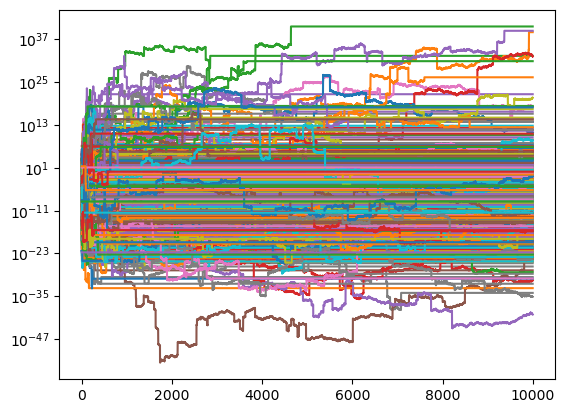

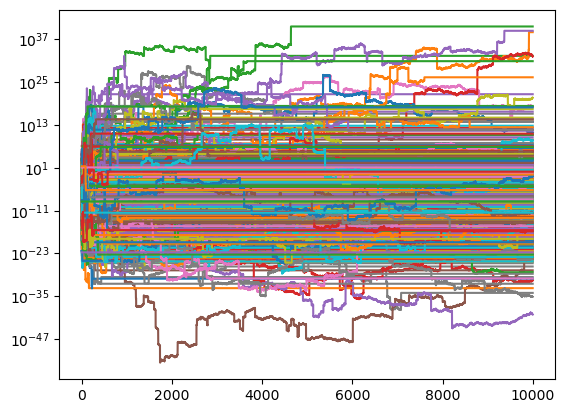

In [6]:
matplotlib.pyplot.close()
fig, ax = subplots()

n_chains = size(mcmc_chains_all, 4)
for i in 1:n_chains
    ax.plot(mcmc_chains_all[2, :, 6, i])
end

println(sum(any(any(mcmc_chains_all[2, :, :, :] .> 1e5, dims=2), dims=4)))

ax.set_yscale(:log)

gcf()

In [3]:
using JLD2, StaticArrays, CUDA

# param_arr = load("independent_large_rmse_indices_2026-08-11_203037.jld2", "problematic_params")
param_arr = load("smc_params_independent_step2_mut2878.jld2", "p")

param_key_mapping = [
    :rho_s,
    :mu_O, :neg_delta_O,
    :mu_R, :neg_delta_R,
    :mu_H, :neg_delta_H,
    :mu_X, :neg_delta_X,
    :mu_Y, :neg_delta_Y,
    :c_ex, :P_I, :P_C, :K_s,
    :lambda_I, :lambda_C,
    :k_gamma, :k_omega,
    :K_I, :n, :K_b
]

# println(param_arr[1, :])

times, sources, densities, lab_means, CIs, CI_widths, uncert_lab = unpack_ijadpanahsaravi_data()

germination_all = model_wrapper("independent", param_arr, Float32.(times .* 3600))

println(size(germination_all))

N = length(times)
n_samples = size(param_arr, 1)
times_s = SVector{N,Float32}(times)
pobs_all = [SVector{N,Float32}(@view germination_all[k, :]) for k in 1:n_samples]
u0_all = [SVector{3,Float32}(0f0, log(times[N÷2+1]), log(2f0)) for _ in 1:n_samples]  # a0=logit(0.5)=0
results, rmses = fit_all_curves(times_s, CUDA.cu(pobs_all), CUDA.cu(u0_all); backend=CUDA.CUDABackend())
results_host = Array(results)
dantigny_summaries = reduce(hcat, results_host)                # 3 × n_samples, same layout as before
rmse_vals = Array(rmses)

dantigny_summaries_2 = zeros(Float64, 3, n_samples) # 3 parameters (p_max, tau_g, nu) X n_samples_total
rmse_vals_2 = Vector{Float64}(undef, n_samples)

for k in 1:n_samples
    if any(isinf.(germination_all[k, :]) .|| isnan.(germination_all[k, :]))
        println(germination_all[k, :])
        println(param_arr[k, :])
    end
    p_opt, rmse = fit_dantigny_to_germination_curve(germination_all[k, :], times[:])
    dantigny_summaries_2[:, k] .= p_opt
    rmse_vals_2[k] = rmse
end

matplotlib.pyplot.close()
fig, ax = subplots()
for n in 1:n_samples
    println("Parameters $(collect(zip(param_key_mapping, param_arr[n, :])))\nRMSE=$(rmse_vals[n])")
    println("Alt RMSE=$(rmse_vals_2[n])")
    # println("Parameters $(param_arr[n, :])")
    println("Fit: $(dantigny_summaries[:, n])")
    dantigny_summaries[1, n] = 0.8
    # dantigny_summaries[2, n] = 1
    # dantigny_summaries[3, n] = 4
    # println("Fit: $(dantigny_summaries[:, n])")
    germination_fitted = dantigny.(times, dantigny_summaries[:, n]...)
    germination_fitted_2 = dantigny.(times, dantigny_summaries_2[:, n]...)
    rmse_new = sqrt(mean((germination_all[n, :] .- germination_fitted).^2))
    println("RMSE new: $rmse_new")
    dash_pattern = (n % 10 + 1, n % 7 + 1)
    ax.plot(times, germination_all[n, :], label="$n", alpha=0.8, dashes=dash_pattern)
    ax.plot(times, germination_fitted, label="$n (fit)", alpha=0.8, dashes=dash_pattern)
    ax.plot(times, germination_fitted_2, label="$n (fit 2)", alpha=0.8, dashes=dash_pattern)
end

ax.legend()

# for n in 1:n_samples
#     println(n)
#     germination = model_wrapper("independent", param_arr[n:n, :], Float32.(times))
# end
# germination = model_wrapper("independent", param_arr[396:396, :], Float32.(times))

# fit_params, rmse = fit_dantigny_to_germination_curve(germination[1, :], times)

# println("Fit parameters: ", fit_params)
# println("RMSE: ", rmse)

# fig, ax = subplots()

# ax.plot(times[2:end], germination[1, 2:end])
# ax.plot(times, germination_2)
# ax.plot(times, dantigny.(times, fit_params...))
# # ax.plot(times, germination_3)
# ax.grid()
# ax.set_xlabel("Time [s]")
# ax.set_ylabel("Germination %")
gcf()

(4096, 256)
Float32[NaN, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.99999994, 0.9

ErrorException: Data contains `Inf` or `NaN` values and a fit cannot be performed

In [8]:
exp(-0/0)

NaN

In [6]:
for (i, key) in enumerate(param_key_mapping)
    println(key, "  :   ", param_arr[396, i])
end

rho_s  :   3.3333333e-8
mu_O  :   0.0
neg_delta_O  :   0.0
mu_R  :   2.65
neg_delta_R  :   0.3
mu_H  :   0.2
neg_delta_H  :   0.05
mu_X  :   0.003214596
neg_delta_X  :   -0.0109317005
mu_Y  :   3.3253748e-6
neg_delta_Y  :   0.94410294
c_ex  :   0.01
P_I  :   0.0060632774
P_C  :   0.0030752409
K_s  :   0.00033945884
lambda_I  :   0.0
lambda_C  :   0.0
k_gamma  :   0.0
k_omega  :   0.0
K_I  :   0.0
n  :   0.0
K_b  :   0.0


## References